In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
print(df.shape)

(32561, 15)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
print("Duplicate Rows:", {df.duplicated().sum()})
print(df.nunique())

Duplicate Rows: {np.int64(24)}
age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,32561.0,NaN,NaN,NaN,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
workclass,32561,9,Private,22696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,32561.0,NaN,NaN,NaN,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education,32561,16,HS-grad,10501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education.num,32561.0,NaN,NaN,NaN,10.080679,2.57272,1.0,9.0,10.0,12.0,16.0
marital.status,32561,7,Married-civ-spouse,14976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,32561,15,Prof-specialty,4140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,32561,6,Husband,13193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,32561,5,White,27816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,32561,2,Male,21790,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = df.replace('?', np.nan)

print("Missing values per column: ")
print(df.isnull().sum()[df.isnull().sum()>0])

Missing values per column: 
workclass         1836
occupation        1843
native.country     583
dtype: int64


In [ ]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (32537, 15)


In [ ]:
target_col = "income"
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != target_col]

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


income
<=50K    24698
>50K      7839
Name: count, dtype: int64
income
<=50K    75.907428
>50K     24.092572
Name: proportion, dtype: float64


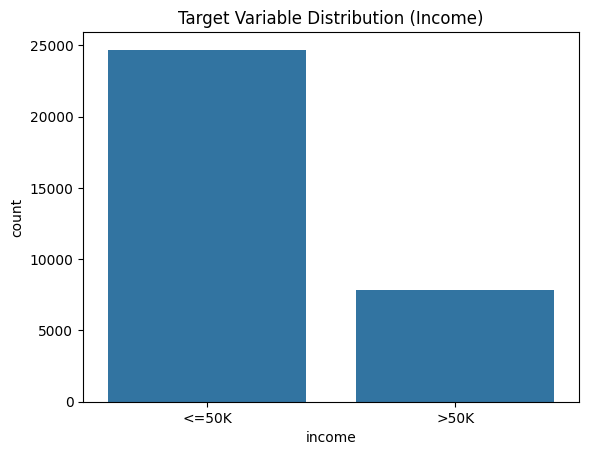

In [ ]:
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True)*100)

plt.figure()
sns.countplot(x=target_col, data=df)
plt.title("Target Variable Distribution (Income)")
plt.show()

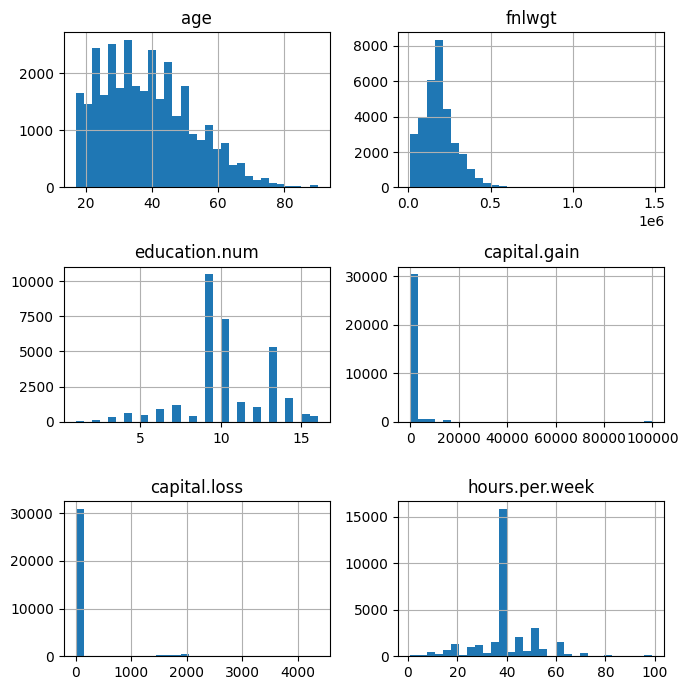

In [ ]:
df[num_cols].hist(figsize=(7,7), bins=30)
plt.tight_layout()
plt.show()

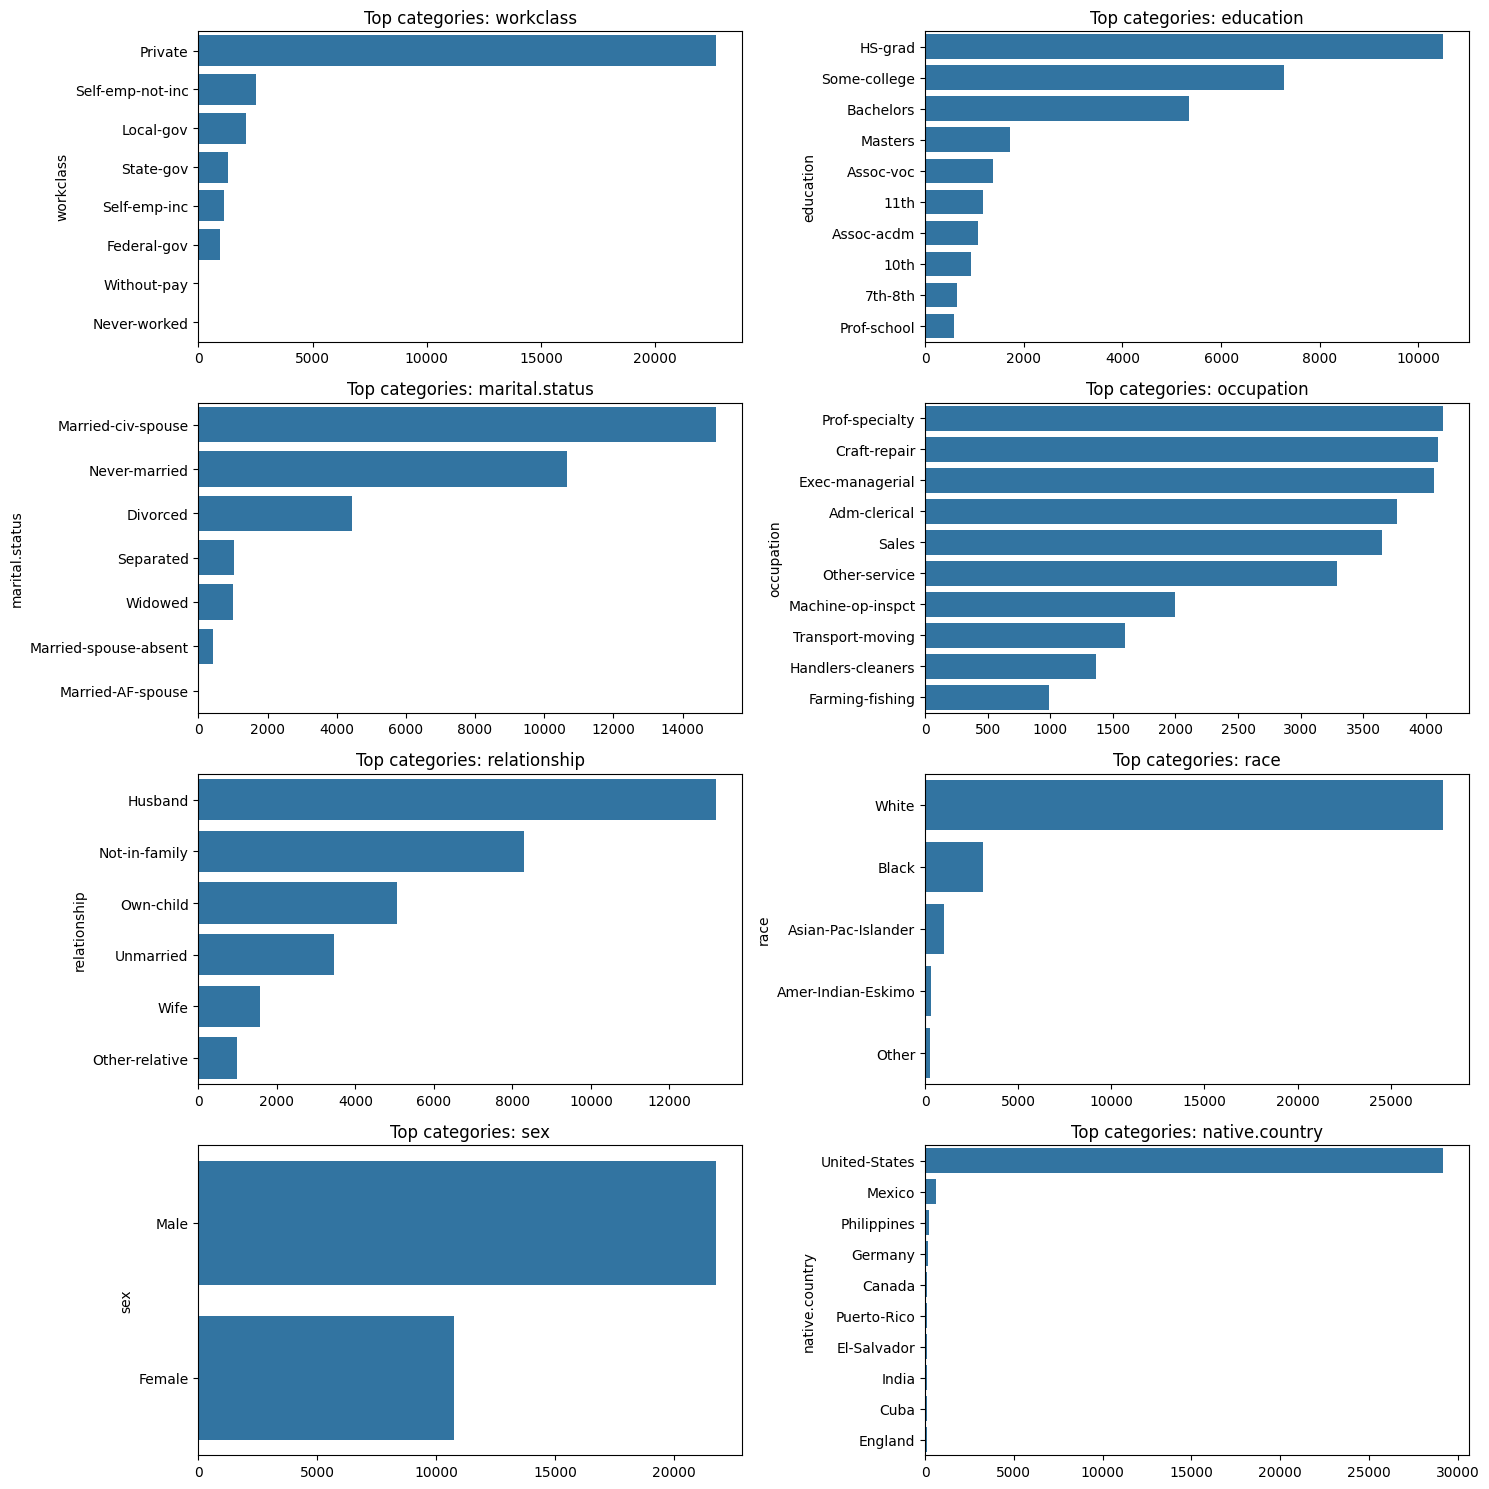

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    top_vals = df[col].value_counts().nlargest(10)
    sns.barplot(x=top_vals.values, y=top_vals.index, ax=axes[i])
    axes[i].set_title(f"Top categories: {col}")
plt.tight_layout()
plt.show()

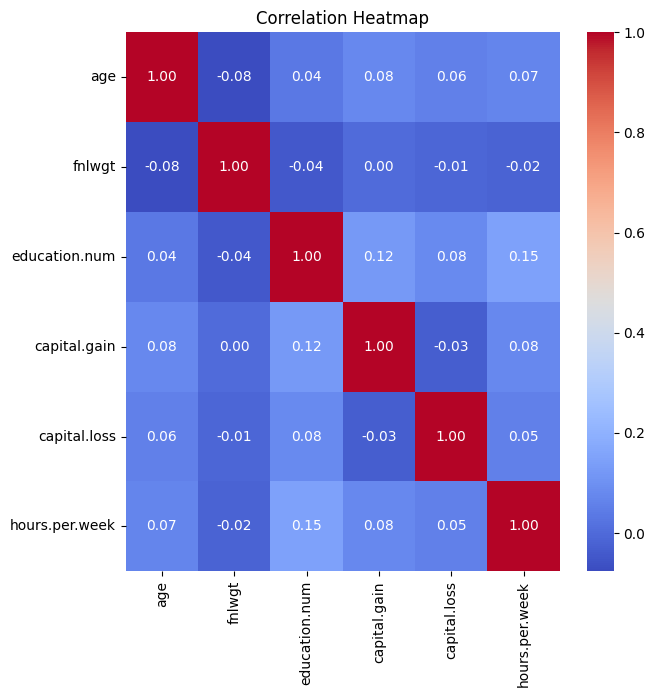

In [ ]:
plt.figure(figsize=(7,7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

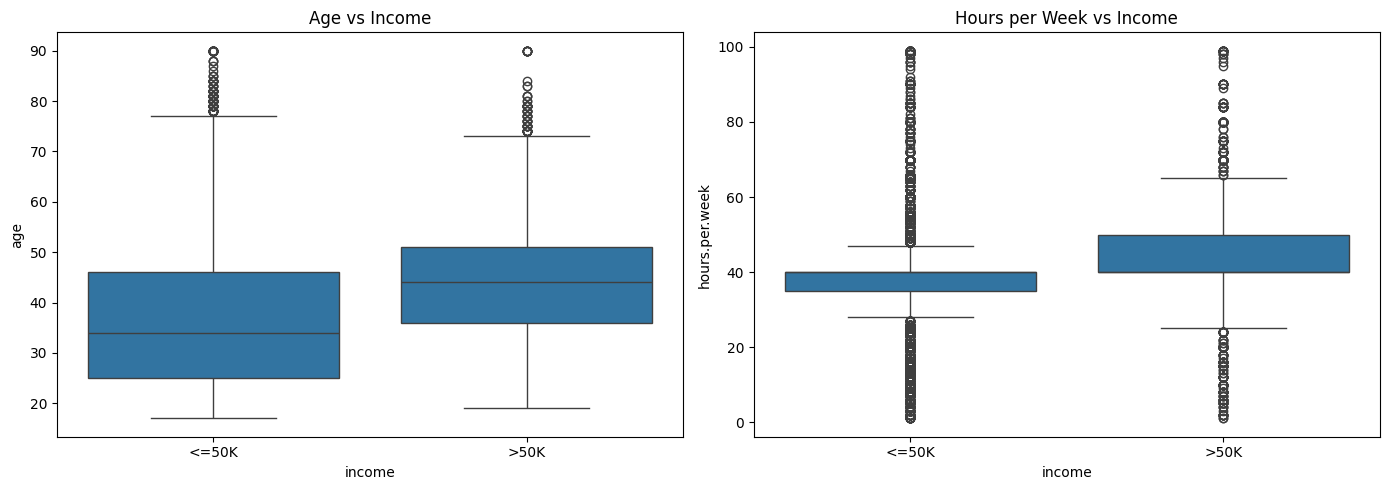

In [ ]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
sns.boxplot(x=target_col, y='age', data=df, ax=axes[0])
axes[0].set_title("Age vs Income")
sns.boxplot(x=target_col, y='hours.per.week', data=df, ax=axes[1])
axes[1].set_title("Hours per Week vs Income")
plt.tight_layout()
plt.show()

# **EDA**

In [ ]:
df_model = df.drop(columns=["fnlwgt", "education"])
cat_cols_model = [c for c in df_model.select_dtypes(include=['object']).columns if c != target_col]
for col in cat_cols_model:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

print(df_model.isnull().sum())


age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [ ]:
df_model[target_col] = df_model[target_col].apply(lambda x: 1 if x.strip() == '>50K' else 0)
df_model[target_col].value_counts()

,count
income,
0,24698
1,7839


In [ ]:
df_model["capital.net"] = df_model["capital.gain"] - df_model["capital.loss"]

X=df_model.drop(columns=[target_col])
y=df_model[target_col]

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", num_features)
print("Categorical columns:", cat_features)

Numerical columns: ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'capital.net']
Categorical columns: ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_features)
    ]
)

In [ ]:
df_model.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net
0,90,Private,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,0,-4356
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0,-4356
2,66,Private,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,0,-4356
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0,-3900
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0,-3900


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (26029, 13)
Test Shape: (6508, 13)


In [ ]:
models = {
    'RandomForestClassifier':{
        'model': RandomForestClassifier(random_state=42),
        'params' :{
            'classifier__n_estimators':[100,200],
            'classifier__max_depth':[10,20],
            'classifier__min_samples_leaf':[1,2]
        }
    },
    'AdaBoostClassifier':{
        'model': AdaBoostClassifier(random_state=42),
        'params':{
            'classifier__n_estimators':[50,100,200],
            'classifier__learning_rate':[0.01,0.1,0.5]
        }
    },
    'XGBoostClassifier':{
        'model': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
        'params':{
            'classifier__n_estimators':[100,200],
            'classifier__max_depth':[3,5],
            'classifier__learning_rate':[0.01,0.1]
        }
    }
}

model_results = {}

for name, model_info in models.items():
    print(f"\nTraining {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),('classifier', model_info['model'])])

    grid_search = GridSearchCV(pipeline, model_info['params'], cv=3, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train,y_train)

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    model_results[name]={
        'model': best_model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc_score': roc_auc,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    }

    print(f"{name} - Best Parameters: {grid_search.best_params_}")
    print(f"{name} - Accuracy: {accuracy:.4f}")
    print(f"{name} - F1 Score: {f1:.4f}")


Training RandomForestClassifier...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


RandomForestClassifier - Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
RandomForestClassifier - Accuracy: 0.8594
RandomForestClassifier - F1 Score: 0.6657

Training AdaBoostClassifier...
Fitting 3 folds for each of 9 candidates, totalling 27 fits


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


AdaBoostClassifier - Best Parameters: {'classifier__learning_rate': 0.5, 'classifier__n_estimators': 200}
AdaBoostClassifier - Accuracy: 0.8523
AdaBoostClassifier - F1 Score: 0.6339

Training XGBoostClassifier...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:42:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoostClassifier - Best Parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
XGBoostClassifier - Accuracy: 0.8677
XGBoostClassifier - F1 Score: 0.6991


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### Model Evaluation Comparison

In [ ]:
evaluation_df = pd.DataFrame({
    'Model':[],
    'Accuracy':[],
    'Precision':[],
    'Recall':[],
    'F1-Score':[],
    'ROC-AUC Score':[]
})

for name, metrics in model_results.items():
    new_row = pd.DataFrame([{
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1_score'],
        'ROC-AUC Score': metrics['roc_auc_score']
    }])
    evaluation_df = pd.concat([evaluation_df, new_row], ignore_index=True)

display(evaluation_df.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC Score
2,XGBoostClassifier,0.867701,0.773395,0.637755,0.699056,0.922071
0,RandomForestClassifier,0.859404,0.779299,0.580995,0.665692,0.913085
1,AdaBoostClassifier,0.852336,0.787133,0.530612,0.633905,0.902613


### Confusion Matrices

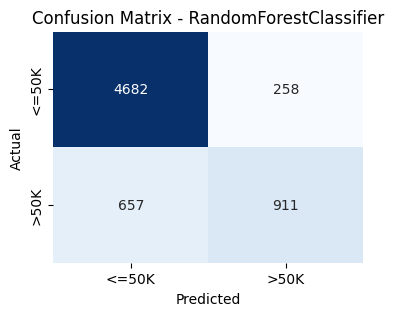

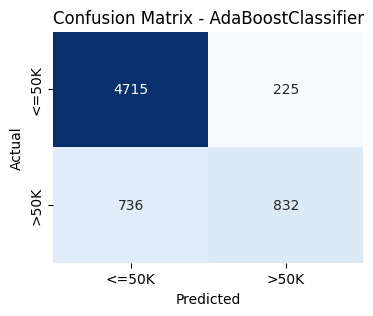

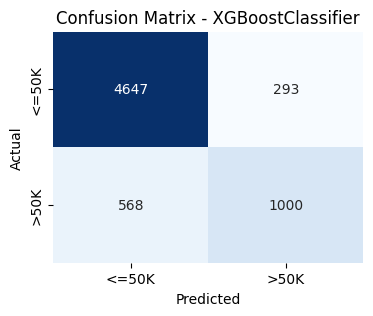

In [ ]:
for name, metrics in model_results.items():
  cm  = metrics['confusion_matrix']
  plt.figure(figsize=(4,3))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
  plt.title(f'Confusion Matrix - {name}')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

### Feature Importance

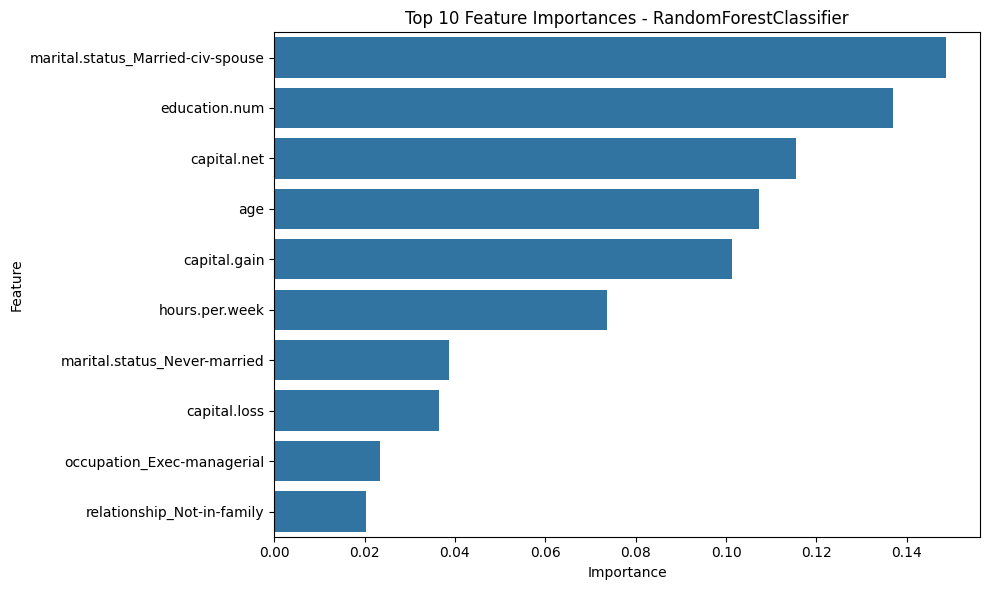

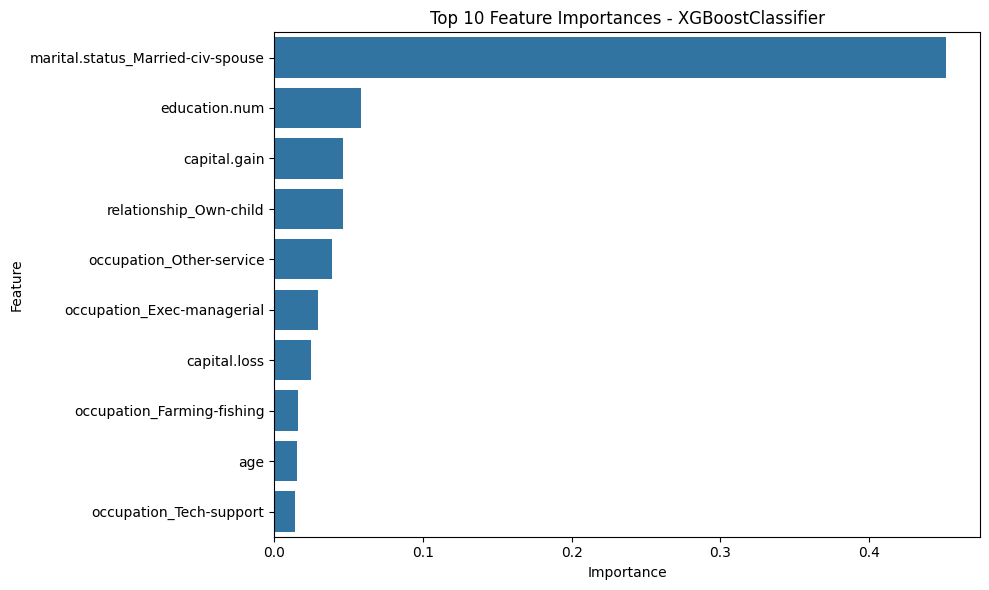

In [ ]:
def plot_feature_importance(model, feature_names, title, top_n=10):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(top_n)
    plt.figure(figsize=(10, 6))

    sns.barplot(x='importance', y='feature', data=feature_importance_df)
    plt.title(f'Top {top_n} Feature Importances - {title}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')

    plt.tight_layout()
    plt.show()

onehot_features = model_results['RandomForestClassifier']['model'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_feature_names = num_features + list(onehot_features)

for name, result in model_results.items():
    if name in ['RandomForestClassifier', 'XGBoostClassifier']:
        plot_feature_importance(result['model'].named_steps['classifier'], all_feature_names, name)

# **Top 10 Feature Importances**

**Marital.Status_Married-civ-spouse:** Being married to a civilian spouse often correlates with higher household income may also be higher due to combined financial planning.

**Education Number:** This represents the number of years of education. Higher Education level typically leads to better job opportunities.

**Capital Gain/Loss:** A higher capital gain or lower capital loss often correlates with higher income.

**Relationship (Various Categories):** Similar to marital status, these relationship categories are highly indicative, as these roles often come with established careers & higher earning potential within a family unit.

**Occupation (Various Categories):** Certain occupations inherently pay more than others. Features representing these high paying professions naturally have high importance.

**Hours Per Week:** The number of hours worked per week directly influences income, especially for hourly wage earners or those with overtime.

**Age:** Income tends to increase with age as individuals gain experience and advance in their careers, peaking before retirement.

In [ ]:
df_model.to_csv('processed_adult.csv', index=False)
print('Processed data saved to processed_adult.csv')

Processed data saved to processed_adult.csv


In [ ]:
df1 = pd.read_csv('processed_adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
